# AniSOAP + explicit rank-2 orientation tensors

This clean diagnostic compares radial coordinates, explicit rank-2 orientation
invariants, averaged AniSOAP, and their concatenation on `random_rotations.xyz`.

It uses no metatrain. Every model uses the same fixed fit/validation/test split
and `StandardFlexibleScaler(column_wise=False)`.


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from ase.io import read
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from skmatter.preprocessing import StandardFlexibleScaler

from anisoap.representations import EllipsoidalDensityProjection

BENCHMARK_DIR = Path(
    "/Users/rca/source_installs/anisoap/"
    "benchmarks/two_particle_gb/force_and_torque_benchmarks"
)
XYZ_PATH = BENCHMARK_DIR / "random_rotations.xyz"

if not XYZ_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {XYZ_PATH}")

if str(BENCHMARK_DIR) not in sys.path:
    sys.path.insert(0, str(BENCHMARK_DIR))

from orientation_tensor_features import (
    OrientationTensorConfig,
    global_rotation_invariance_error,
    orientation_tensor_features,
)

print("dataset:", XYZ_PATH)


dataset: /Users/rca/source_installs/anisoap/benchmarks/two_particle_gb/force_and_torque_benchmarks/random_rotations.xyz


In [3]:
STRIDE = 5
frames = read(XYZ_PATH, index=f"::{STRIDE}")

def frame_energy(frame):
    for key in ("energy", "Energy", "free_energy"):
        if key in frame.info:
            return float(frame.info[key])
    try:
        return float(frame.get_potential_energy())
    except Exception as exc:
        raise KeyError(
            f"Could not find an energy target in frame.info: {frame.info.keys()}"
        ) from exc

energies = np.array([frame_energy(frame) for frame in frames])
distances = np.array(
    [np.linalg.norm(frame.positions[1] - frame.positions[0]) for frame in frames]
)

print("frames:", len(frames))
print("energy range:", energies.min(), energies.max())
print("energy std:", energies.std())
print("distance range:", distances.min(), distances.max())


frames: 455
energy range: -0.9870706275897596 -0.0597725093451465
energy std: 0.19444393387272874
distance range: 2.215312060421632 3.4074805108809985


In [12]:
frames[0].arrays

{'numbers': array([0, 0]),
 'positions': array([[10.        , 10.        , 10.        ],
        [11.55830549, 11.72048156, 11.4576743 ]]),
 'quaternions': array([[ 0.34998225,  0.79609413, -0.37895701,  0.31644611],
        [-0.57715661, -0.03939377,  0.80060493, -0.15610932]]),
 'c_diameter[1]': array([1., 1.]),
 'c_diameter[2]': array([1.5, 1.5]),
 'c_diameter[3]': array([2., 2.]),
 'torques': array([[ 1.49837457, -0.21759763, -0.4568521 ],
        [-0.35812842, -1.8460283 ,  2.81048167]])}

## Configure the body-frame shape tensor

`(1, 1, 3)` is a uniaxial prolate diagnostic. Replace it with the actual
principal-axis shape values used by the benchmark when known. Only relative
anisotropy matters because the isotropic trace is removed.


In [13]:
tensor_config = OrientationTensorConfig(
    shape_eigenvalues=(1.0, 1.5, 2.0),
    quaternion_order="wxyz",
    include_distance=True,
    include_inverse_distance=True,
    include_radial_products=True,
)

X_tensor, tensor_names = orientation_tensor_features(frames, tensor_config)

print("tensor feature shape:", X_tensor.shape)
for name in tensor_names:
    print(" ", name)

invariance_error = global_rotation_invariance_error(
    frames[len(frames) // 2],
    tensor_config,
)
print("global-rotation invariance max error:", invariance_error)

if invariance_error > 1e-10:
    raise RuntimeError(
        "Orientation features failed the invariance check. "
        "Check quaternion ordering and storage."
    )


tensor feature shape: (455, 23)
  distance
  inverse_distance
  Q0r_plus_Q1r
  Q0r_times_Q1r
  abs_Q0r_minus_Q1r
  trace_Q0Q1
  r_Q0Q1_plus_Q1Q0_r
  antisymmetric_mixed_squared
  trace_Q0sq_plus_Q1sq
  distance_times_Q0r_plus_Q1r
  distance_times_Q0r_times_Q1r
  distance_times_abs_Q0r_minus_Q1r
  distance_times_trace_Q0Q1
  distance_times_r_Q0Q1_plus_Q1Q0_r
  distance_times_antisymmetric_mixed_squared
  distance_times_trace_Q0sq_plus_Q1sq
  Q0r_plus_Q1r_over_distance
  Q0r_times_Q1r_over_distance
  abs_Q0r_minus_Q1r_over_distance
  trace_Q0Q1_over_distance
  r_Q0Q1_plus_Q1Q0_r_over_distance
  antisymmetric_mixed_squared_over_distance
  trace_Q0sq_plus_Q1sq_over_distance
global-rotation invariance max error: 2.6645352591003757e-15


In [5]:
calculator = EllipsoidalDensityProjection(
    max_angular=9,
    max_radial=9,
    radial_basis_name="gto",
    cutoff_radius=4.5,
    radial_gaussian_width=1.0,
    rotation_key="quaternions",
    rotation_type="quaternion",
    dtype=torch.float64,
)

with torch.no_grad():
    raw = calculator.power_spectrum(
        frames=frames,
        mean_over_samples=True,
        normalize=False,
        show_progress=False,
    )

if isinstance(raw, torch.Tensor):
    X_anisoap = raw.detach().cpu().numpy()
else:
    block = raw.block(0)
    X_anisoap = block.values.detach().cpu().numpy()
    while X_anisoap.ndim > 2 and X_anisoap.shape[1] == 1:
        X_anisoap = X_anisoap[:, 0]

X_anisoap = np.asarray(X_anisoap)

if X_anisoap.ndim != 2 or X_anisoap.shape[0] != len(frames):
    raise ValueError(f"Unexpected AniSOAP shape: {X_anisoap.shape}")

print("AniSOAP shape:", X_anisoap.shape)
print("finite:", np.isfinite(X_anisoap).all())


AniSOAP shape: (455, 1000)
finite: True


In [14]:
indices = np.arange(len(frames))
train_indices, test_indices = train_test_split(
    indices, test_size=0.20, random_state=0
)
fit_indices, validation_indices = train_test_split(
    train_indices, test_size=0.20, random_state=1
)

print("fit:", len(fit_indices))
print("validation:", len(validation_indices))
print("test:", len(test_indices))


fit: 291
validation: 73
test: 91


In [15]:
def metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    return {
        "rmse": rmse,
        "relative_rmse": rmse / np.std(y_true),
        "r2": r2_score(y_true, y_pred),
    }

def print_metrics(label, y_true, y_pred):
    result = metrics(y_true, y_pred)
    print(
        f"{label:32s} "
        f"RMSE={result['rmse']:.6f}  "
        f"relative RMSE={result['relative_rmse']:.3f}  "
        f"R²={result['r2']:+.3f}"
    )
    return result

X_radial = np.column_stack([
    distances,
    1.0 / distances,
    distances**2,
    1.0 / distances**2,
    1.0 / distances**6,
    1.0 / distances**12,
])

feature_sets = {
    "radial only": X_radial,
    "orientation tensor": X_tensor,
    "AniSOAP": X_anisoap,
    "AniSOAP + tensor": np.concatenate([X_anisoap, X_tensor], axis=1),
}

for name, matrix in feature_sets.items():
    print(f"{name:22s}", matrix.shape, "finite:", np.isfinite(matrix).all())


radial only            (455, 6) finite: True
orientation tensor     (455, 23) finite: True
AniSOAP                (455, 1000) finite: True
AniSOAP + tensor       (455, 1023) finite: True


## Linear control


In [16]:
ridge_alphas = np.logspace(-8, 8, 33)
ridge_results = {}

for feature_name, features in feature_sets.items():
    best_alpha = None
    best_validation_rmse = np.inf

    for alpha in ridge_alphas:
        model = make_pipeline(
            StandardFlexibleScaler(column_wise=False),
            Ridge(alpha=alpha),
        )
        model.fit(features[fit_indices], energies[fit_indices])
        pred = model.predict(features[validation_indices])
        rmse = mean_squared_error(energies[validation_indices], pred) ** 0.5

        if rmse < best_validation_rmse:
            best_validation_rmse = rmse
            best_alpha = alpha

    final_model = make_pipeline(
        StandardFlexibleScaler(column_wise=False),
        Ridge(alpha=best_alpha),
    )
    final_model.fit(features[train_indices], energies[train_indices])

    train_pred = final_model.predict(features[train_indices])
    test_pred = final_model.predict(features[test_indices])

    print(f"\nRidge: {feature_name}")
    print("selected alpha:", best_alpha)
    print_metrics("train", energies[train_indices], train_pred)
    test_metrics = print_metrics("test", energies[test_indices], test_pred)

    ridge_results[feature_name] = {
        "model": final_model,
        "prediction": test_pred,
        "metrics": test_metrics,
        "alpha": best_alpha,
    }



Ridge: radial only
selected alpha: 3.162277660168379e-07
train                            RMSE=0.152082  relative RMSE=0.764  R²=+0.416
test                             RMSE=0.145727  relative RMSE=0.864  R²=+0.254

Ridge: orientation tensor
selected alpha: 0.0001
train                            RMSE=0.149890  relative RMSE=0.753  R²=+0.432
test                             RMSE=0.149569  relative RMSE=0.887  R²=+0.214

Ridge: AniSOAP
selected alpha: 1e-08
train                            RMSE=0.166279  relative RMSE=0.836  R²=+0.302
test                             RMSE=0.153003  relative RMSE=0.907  R²=+0.177

Ridge: AniSOAP + tensor
selected alpha: 1e-08
train                            RMSE=0.166279  relative RMSE=0.836  R²=+0.302
test                             RMSE=0.153003  relative RMSE=0.907  R²=+0.177


## Nonlinear control: RBF kernel ridge


In [17]:
krr_alphas = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]
krr_gammas = np.logspace(-8, 1, 19)
krr_results = {}

for feature_name, features in feature_sets.items():
    best = None
    best_validation_rmse = np.inf

    for alpha in krr_alphas:
        for gamma in krr_gammas:
            model = make_pipeline(
                StandardFlexibleScaler(column_wise=False),
                KernelRidge(
                    alpha=alpha,
                    kernel="rbf",
                    gamma=float(gamma),
                ),
            )
            model.fit(features[fit_indices], energies[fit_indices])
            pred = model.predict(features[validation_indices])
            rmse = mean_squared_error(energies[validation_indices], pred) ** 0.5

            if rmse < best_validation_rmse:
                best_validation_rmse = rmse
                best = {
                    "alpha": alpha,
                    "gamma": float(gamma),
                    "validation_rmse": rmse,
                }

    final_model = make_pipeline(
        StandardFlexibleScaler(column_wise=False),
        KernelRidge(
            alpha=best["alpha"],
            kernel="rbf",
            gamma=best["gamma"],
        ),
    )
    final_model.fit(features[train_indices], energies[train_indices])

    train_pred = final_model.predict(features[train_indices])
    test_pred = final_model.predict(features[test_indices])

    print(f"\nKRR: {feature_name}")
    print("selected:", best)
    print_metrics("train", energies[train_indices], train_pred)
    test_metrics = print_metrics("test", energies[test_indices], test_pred)

    krr_results[feature_name] = {
        "model": final_model,
        "prediction": test_pred,
        "metrics": test_metrics,
        "parameters": best,
    }



KRR: radial only
selected: {'alpha': 0.0001, 'gamma': 0.01, 'validation_rmse': 0.16309912608452226}
train                            RMSE=0.152035  relative RMSE=0.764  R²=+0.416
test                             RMSE=0.145644  relative RMSE=0.863  R²=+0.255

KRR: orientation tensor
selected: {'alpha': 0.1, 'gamma': 0.03162277660168379, 'validation_rmse': 0.16777947257867612}
train                            RMSE=0.151659  relative RMSE=0.762  R²=+0.419
test                             RMSE=0.147374  relative RMSE=0.874  R²=+0.237

KRR: AniSOAP
selected: {'alpha': 0.0001, 'gamma': 3.1622776601683795, 'validation_rmse': 0.17272564134479249}
train                            RMSE=0.149695  relative RMSE=0.752  R²=+0.434
test                             RMSE=0.158208  relative RMSE=0.938  R²=+0.120

KRR: AniSOAP + tensor
selected: {'alpha': 0.0001, 'gamma': 3.1622776601683795, 'validation_rmse': 0.17272564134479249}
train                            RMSE=0.149695  relative RMSE=0.752  R²=+0

In [18]:
rows = []
for model_name, results in (("ridge", ridge_results), ("KRR", krr_results)):
    for feature_name, result in results.items():
        rows.append((
            model_name,
            feature_name,
            result["metrics"]["rmse"],
            result["metrics"]["relative_rmse"],
            result["metrics"]["r2"],
        ))

rows.sort(key=lambda row: row[2])
print(f"{'model':8s} {'features':24s} {'RMSE':>10s} {'rel.RMSE':>10s} {'R²':>9s}")
for model_name, feature_name, rmse, rel, r2 in rows:
    print(
        f"{model_name:8s} {feature_name:24s} "
        f"{rmse:10.6f} {rel:10.3f} {r2:9.3f}"
    )


model    features                       RMSE   rel.RMSE        R²
KRR      radial only                0.145644      0.863     0.255
ridge    radial only                0.145727      0.864     0.254
KRR      orientation tensor         0.147374      0.874     0.237
ridge    orientation tensor         0.149569      0.887     0.214
ridge    AniSOAP                    0.153003      0.907     0.177
ridge    AniSOAP + tensor           0.153003      0.907     0.177
KRR      AniSOAP                    0.158208      0.938     0.120
KRR      AniSOAP + tensor           0.158208      0.938     0.120


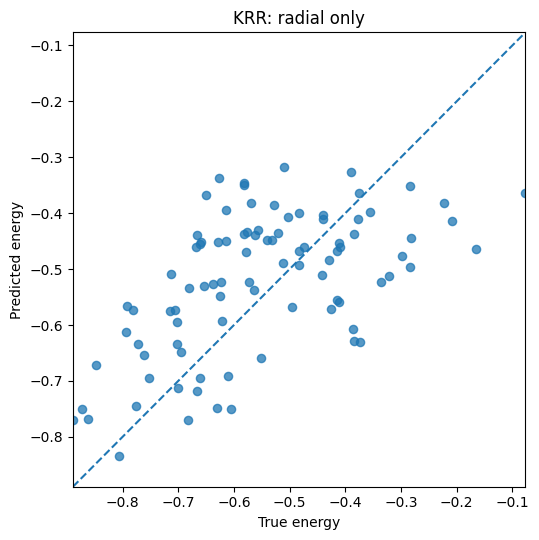

In [19]:
best_model_name, best_feature_name, *_ = rows[0]
best_result = (
    ridge_results if best_model_name == "ridge" else krr_results
)[best_feature_name]

truth = energies[test_indices]
prediction = best_result["prediction"]

limits = [
    min(truth.min(), prediction.min()),
    max(truth.max(), prediction.max()),
]

plt.figure(figsize=(5.5, 5.5))
plt.scatter(truth, prediction, s=35, alpha=0.75)
plt.plot(limits, limits, linestyle="--")
plt.xlim(limits)
plt.ylim(limits)
plt.xlabel("True energy")
plt.ylabel("Predicted energy")
plt.title(f"{best_model_name}: {best_feature_name}")
plt.tight_layout()
plt.show()


## Reading the outcome

- **Tensor beats radial:** explicit orientation geometry carries useful signal.
- **AniSOAP + tensor beats AniSOAP:** useful orientation coordinates are missing
  or obscured in the current power spectrum.
- **Tensor alone rivals the combined model:** a compact pair representation may
  be sufficient for this benchmark.
- **No improvement:** verify actual shape eigenvalues and quaternion convention.
- **KRR beats ridge strongly:** the energy is nonlinear in these invariants.


In [20]:
# The helper places distance and inverse distance first.
X_tensor_radial = X_tensor[:, :2]
X_tensor_orientation = X_tensor[:, 2:]

tensor_ablation_sets = {
    "distance + inverse distance": X_tensor_radial,
    "orientation only": X_tensor_orientation,
    "full tensor": X_tensor,
}

for name, matrix in tensor_ablation_sets.items():
    print(name, matrix.shape)

distance + inverse distance (455, 2)
orientation only (455, 21)
full tensor (455, 23)


In [21]:
tensor_ablation_results = {}

for feature_name, features in tensor_ablation_sets.items():
    best_alpha = None
    best_validation_rmse = np.inf

    for alpha in ridge_alphas:
        model = make_pipeline(
            StandardFlexibleScaler(column_wise=False),
            Ridge(alpha=alpha),
        )

        model.fit(
            features[fit_indices],
            energies[fit_indices],
        )

        pred = model.predict(
            features[validation_indices]
        )

        rmse = mean_squared_error(
            energies[validation_indices],
            pred,
        ) ** 0.5

        if rmse < best_validation_rmse:
            best_validation_rmse = rmse
            best_alpha = alpha

    final_model = make_pipeline(
        StandardFlexibleScaler(column_wise=False),
        Ridge(alpha=best_alpha),
    )

    final_model.fit(
        features[train_indices],
        energies[train_indices],
    )

    train_pred = final_model.predict(
        features[train_indices]
    )
    test_pred = final_model.predict(
        features[test_indices]
    )

    print(f"\nRidge ablation: {feature_name}")
    print("selected alpha:", best_alpha)

    print_metrics(
        "train",
        energies[train_indices],
        train_pred,
    )

    print_metrics(
        "test",
        energies[test_indices],
        test_pred,
    )


Ridge ablation: distance + inverse distance
selected alpha: 1e-08
train                            RMSE=0.152105  relative RMSE=0.765  R²=+0.416
test                             RMSE=0.145820  relative RMSE=0.864  R²=+0.253

Ridge ablation: orientation only
selected alpha: 0.0001
train                            RMSE=0.149883  relative RMSE=0.753  R²=+0.432
test                             RMSE=0.149559  relative RMSE=0.887  R²=+0.214

Ridge ablation: full tensor
selected alpha: 0.0001
train                            RMSE=0.149890  relative RMSE=0.753  R²=+0.432
test                             RMSE=0.149569  relative RMSE=0.887  R²=+0.214


In [22]:
from sklearn.base import BaseEstimator, TransformerMixin


class SeparateBlockScaler(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        split_index,
        second_block_weight=1.0,
    ):
        self.split_index = split_index
        self.second_block_weight = second_block_weight

    def fit(self, X, y=None):
        X = np.asarray(X)

        self.first_scaler_ = StandardFlexibleScaler(
            column_wise=False,
        )
        self.second_scaler_ = StandardFlexibleScaler(
            column_wise=False,
        )

        self.first_scaler_.fit(
            X[:, :self.split_index]
        )
        self.second_scaler_.fit(
            X[:, self.split_index:]
        )

        return self

    def transform(self, X):
        X = np.asarray(X)

        first = self.first_scaler_.transform(
            X[:, :self.split_index]
        )

        second = self.second_scaler_.transform(
            X[:, self.split_index:]
        )

        return np.concatenate(
            [
                first,
                self.second_block_weight * second,
            ],
            axis=1,
        )

In [23]:
X_combined = np.concatenate(
    [
        X_anisoap,
        X_tensor,
    ],
    axis=1,
)

tensor_weights = [
    0.03,
    0.1,
    0.3,
    1.0,
    3.0,
    10.0,
    30.0,
]

alphas = np.logspace(-8, 8, 33)

best = None
best_validation_rmse = np.inf

for tensor_weight in tensor_weights:
    for alpha in alphas:
        model = make_pipeline(
            SeparateBlockScaler(
                split_index=X_anisoap.shape[1],
                second_block_weight=tensor_weight,
            ),
            Ridge(alpha=alpha),
        )

        model.fit(
            X_combined[fit_indices],
            energies[fit_indices],
        )

        validation_pred = model.predict(
            X_combined[validation_indices]
        )

        validation_rmse = mean_squared_error(
            energies[validation_indices],
            validation_pred,
        ) ** 0.5

        if validation_rmse < best_validation_rmse:
            best_validation_rmse = validation_rmse
            best = {
                "tensor_weight": tensor_weight,
                "alpha": alpha,
                "validation_rmse": validation_rmse,
            }

print("best parameters:", best)

final_model = make_pipeline(
    SeparateBlockScaler(
        split_index=X_anisoap.shape[1],
        second_block_weight=best["tensor_weight"],
    ),
    Ridge(alpha=best["alpha"]),
)

final_model.fit(
    X_combined[train_indices],
    energies[train_indices],
)

train_pred = final_model.predict(
    X_combined[train_indices]
)
test_pred = final_model.predict(
    X_combined[test_indices]
)

print_metrics(
    "separate-block ridge train",
    energies[train_indices],
    train_pred,
)

print_metrics(
    "separate-block ridge test",
    energies[test_indices],
    test_pred,
)

best parameters: {'tensor_weight': 0.03, 'alpha': np.float64(1e-07), 'validation_rmse': 0.16568723898094936}
separate-block ridge train       RMSE=0.148382  relative RMSE=0.746  R²=+0.444
separate-block ridge test        RMSE=0.149893  relative RMSE=0.889  R²=+0.210


{'rmse': 0.14989296763309862,
 'relative_rmse': np.float64(0.8885745554268899),
 'r2': 0.21043525944790487}